In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Caminhos do projeto
ROOT = Path("..") #Notebook esta um nivel abaixo do root
DATA_PATH = ROOT / "data" / "concorrentes.csv"
OUTPUTS_GRAFICOS = ROOT / "outputs" / "graficos"

DATA_PATH


WindowsPath('../data/concorrentes.csv')

In [5]:
df = pd.read_csv(DATA_PATH)

#Visualizaçao rapida 
df 

,concorrente,tipo_preco,faixa_preco_min,faixa_preco_max,nicho_saude,nivel_humanizacao,nivel_complexidade,velocidade_resposta,observacao_curta
0,Cloudia,fixo,449.9,1039.9,sim,media,media,lenta,Boa base multicanal e áudio; demora na respost...
1,Huggy,misto,0.0,989.0,nao,baixa,baixa,rapida,Forte em omnichannel e marketing; conversa eng...
2,Blip,sob_consulta,NaN,NaN,nao,baixa,alta,rapida,Infra robusta e completa; complexa e pouco hum...


In [6]:
# Tipos e Nulos 
print(df.dtypes)
print("\nNulos por coluna:")
print(df.isna().sum())

# Checagem simples de consistencia 
print("\nConcorrentes:", df["concorrente"].unique())
print("Tipos de preço:", df["tipo_preco"].unique())
print("Níveis de humanização:", df["nivel_humanizacao"].unique())
print("Níveis de complexidade:", df["nivel_complexidade"].unique())
print("Velocidade resposta:", df["velocidade_resposta"].unique())

concorrente             object
tipo_preco              object
faixa_preco_min        float64
faixa_preco_max        float64
nicho_saude             object
nivel_humanizacao       object
nivel_complexidade      object
velocidade_resposta     object
observacao_curta        object
dtype: object

Nulos por coluna:
concorrente            0
tipo_preco             0
faixa_preco_min        1
faixa_preco_max        1
nicho_saude            0
nivel_humanizacao      0
nivel_complexidade     0
velocidade_resposta    0
observacao_curta       0
dtype: int64

Concorrentes: ['Cloudia' 'Huggy' 'Blip']
Tipos de preço: ['fixo' 'misto' 'sob_consulta']
Níveis de humanização: ['media' 'baixa']
Níveis de complexidade: ['media' 'baixa' 'alta']
Velocidade resposta: ['lenta' 'rapida']


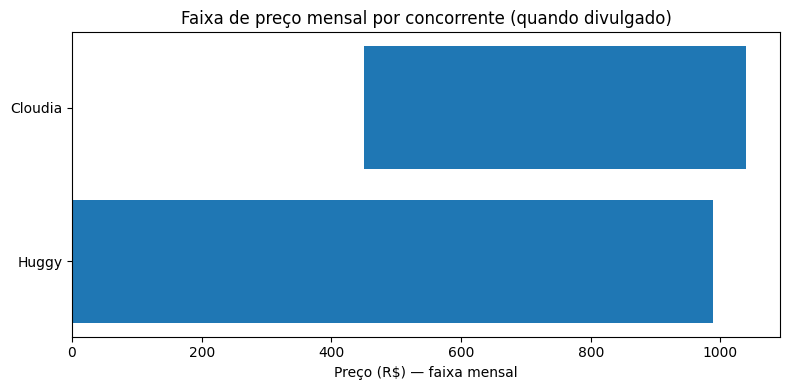

In [7]:
# Filtra só quem tem faixa de preço numérica
df_preco = df.copy()

# Converte para número (se vier vazio vira NaN)
df_preco["faixa_preco_min"] = pd.to_numeric(df_preco["faixa_preco_min"], errors="coerce")
df_preco["faixa_preco_max"] = pd.to_numeric(df_preco["faixa_preco_max"], errors="coerce")

df_preco = df_preco.dropna(subset=["faixa_preco_min", "faixa_preco_max"]).copy()

# Ordena por preço máximo (para leitura melhor)
df_preco = df_preco.sort_values(by="faixa_preco_max")

# Preparar dados para plotar "range" (min→max)
labels = df_preco["concorrente"].tolist()
mins = df_preco["faixa_preco_min"].to_numpy()
maxs = df_preco["faixa_preco_max"].to_numpy()
ranges = maxs - mins

plt.figure(figsize=(8, 4))
plt.barh(labels, ranges, left=mins)
plt.xlabel("Preço (R$) — faixa mensal")
plt.title("Faixa de preço mensal por concorrente (quando divulgado)")
plt.tight_layout()

# (Opcional) salvar no outputs
OUTPUTS_GRAFICOS.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUTS_GRAFICOS / "faixa_preco_concorrentes.png", dpi=200)

plt.show()


In [8]:
df_pos = df.copy()

map_3 = {"baixa": 1, "media": 2, "alta": 3}
map_vel = {"lenta": 1, "media": 2, "rapida": 3}

df_pos["humanizacao_score"] = df_pos["nivel_humanizacao"].map(map_3)
df_pos["complexidade_score"] = df_pos["nivel_complexidade"].map(map_3)
df_pos["velocidade_score"] = df_pos["velocidade_resposta"].map(map_vel)

# Checagem rápida (se tiver NaN aqui, tem texto fora do padrão)
df_pos[["concorrente","nivel_humanizacao","humanizacao_score","nivel_complexidade","complexidade_score","velocidade_resposta","velocidade_score"]]


,concorrente,nivel_humanizacao,humanizacao_score,nivel_complexidade,complexidade_score,velocidade_resposta,velocidade_score
0,Cloudia,media,2,media,2,lenta,1
1,Huggy,baixa,1,baixa,1,rapida,3
2,Blip,baixa,1,alta,3,rapida,3


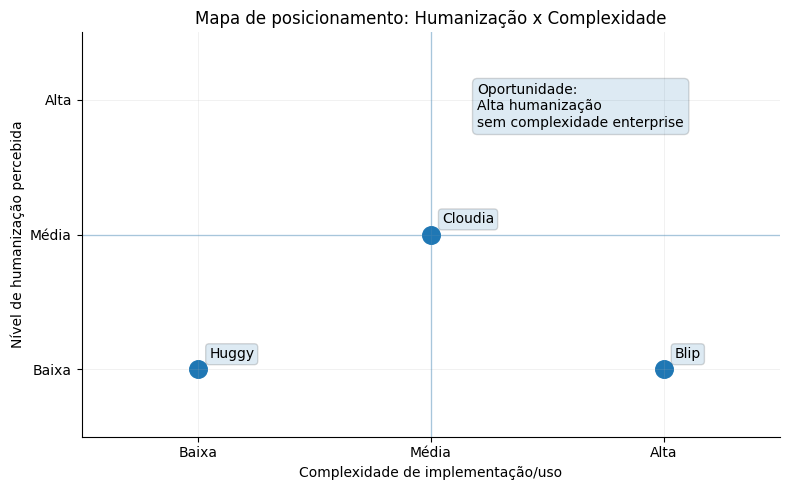

In [9]:
plt.figure(figsize=(8, 5))

x = df_pos["complexidade_score"]
y = df_pos["humanizacao_score"]

plt.scatter(x, y, s=160)

for _, row in df_pos.iterrows():
    plt.annotate(
        row["concorrente"],
        (row["complexidade_score"], row["humanizacao_score"]),
        xytext=(8, 8),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.15),
    )

plt.xlim(0.5, 3.5)
plt.ylim(0.5, 3.5)
plt.xticks([1, 2, 3], ["Baixa", "Média", "Alta"])
plt.yticks([1, 2, 3], ["Baixa", "Média", "Alta"])

# linhas de quadrante (meio)
plt.axvline(2, linewidth=1, alpha=0.35)
plt.axhline(2, linewidth=1, alpha=0.35)

plt.grid(True, linewidth=0.6, alpha=0.20)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Complexidade de implementação/uso")
plt.ylabel("Nível de humanização percebida")
plt.title("Mapa de posicionamento: Humanização x Complexidade")

# anotação "oportunidade"
plt.annotate(
    "Oportunidade:\nAlta humanização\nsem complexidade enterprise",
    (2.2, 2.8),
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.15)
)

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "posicionamento_humanizacao_vs_complexidade_quadrantes.png", dpi=200)
plt.show()




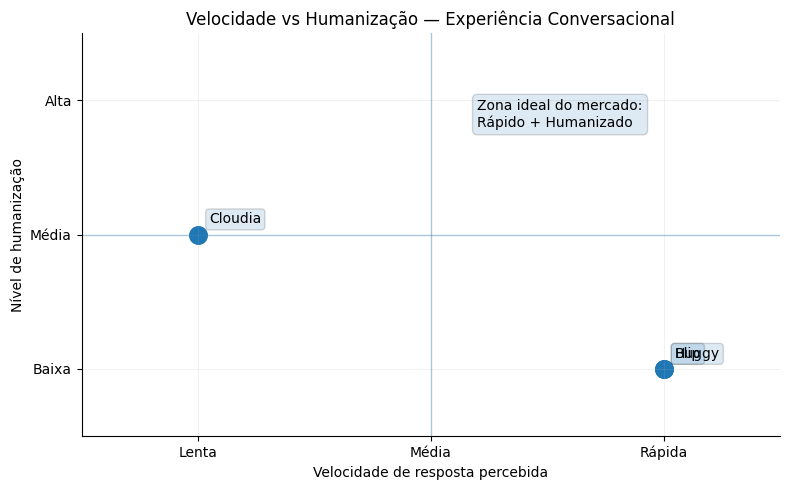

In [10]:
plt.figure(figsize=(8, 5))

x = df_pos["velocidade_score"]
y = df_pos["humanizacao_score"]

plt.scatter(x, y, s=160)

for _, row in df_pos.iterrows():
    plt.annotate(
        row["concorrente"],
        (row["velocidade_score"], row["humanizacao_score"]),
        xytext=(8, 8),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.15),
    )

plt.xlim(0.5, 3.5)
plt.ylim(0.5, 3.5)

plt.xticks([1, 2, 3], ["Lenta", "Média", "Rápida"])
plt.yticks([1, 2, 3], ["Baixa", "Média", "Alta"])

# quadrantes
plt.axvline(2, linewidth=1, alpha=0.35)
plt.axhline(2, linewidth=1, alpha=0.35)

plt.grid(True, linewidth=0.6, alpha=0.20)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Velocidade de resposta percebida")
plt.ylabel("Nível de humanização")
plt.title("Velocidade vs Humanização — Experiência Conversacional")

# anotação estratégica
plt.annotate(
    "Zona ideal do mercado:\nRápido + Humanizado",
    (2.2, 2.8),
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.15)
)

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "velocidade_vs_humanizacao.png", dpi=200)
plt.show()


In [11]:
df_score = df_pos.copy()

# Score de experiência (quanto maior melhor)
df_score["score_experiencia"] = df_score["humanizacao_score"] + df_score["velocidade_score"]

# Score de atrito (quanto maior, mais difícil / mais pesado)
df_score["score_atrito"] = df_score["complexidade_score"]

df_score[["concorrente", "score_experiencia", "score_atrito"]].sort_values("score_experiencia", ascending=False)


,concorrente,score_experiencia,score_atrito
1,Huggy,4,1
2,Blip,4,3
0,Cloudia,3,2


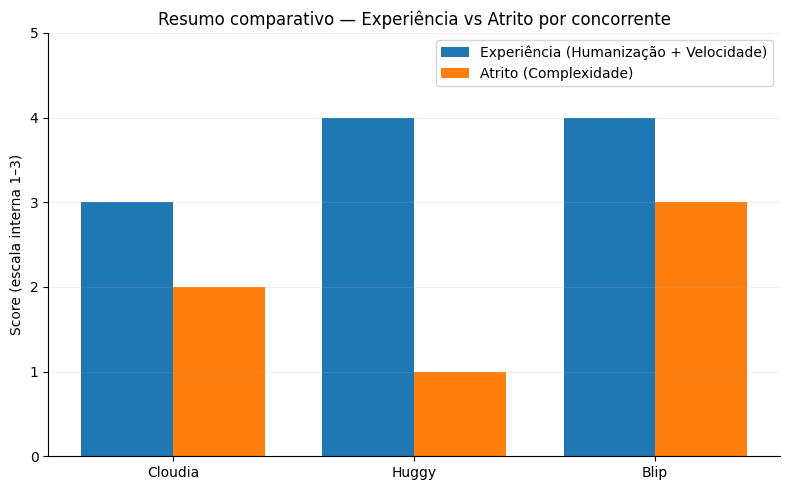

In [12]:
# Ordena por experiência
plot_df = df_score.sort_values("score_experiencia", ascending=True)

labels = plot_df["concorrente"].tolist()
exp = plot_df["score_experiencia"].to_numpy()
atr = plot_df["score_atrito"].to_numpy()

plt.figure(figsize=(8, 5))

# barras lado a lado
x = np.arange(len(labels))
width = 0.38

plt.bar(x - width/2, exp, width, label="Experiência (Humanização + Velocidade)")
plt.bar(x + width/2, atr, width, label="Atrito (Complexidade)")

plt.xticks(x, labels)
plt.ylim(0, max(exp.max(), atr.max()) + 1)

plt.grid(True, axis="y", linewidth=0.6, alpha=0.20)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.ylabel("Score (escala interna 1–3)")
plt.title("Resumo comparativo — Experiência vs Atrito por concorrente")
plt.legend()

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "score_experiencia_vs_atrito.png", dpi=200)
plt.show()


In [13]:
PLANOS_CLOUDIA_PATH = ROOT / "data" / "planos_cloudia.csv"
df_cloudia = pd.read_csv(PLANOS_CLOUDIA_PATH)

# converter preço (vazio vira NaN)
df_cloudia["preco_mensal_brl"] = pd.to_numeric(df_cloudia["preco_mensal_brl"], errors="coerce")

df_cloudia


,plataforma,plano,preco_mensal_brl,usuarios_limite,pacientes_unicos_mes
0,Cloudia,Inicial,449.9,5,200
1,Cloudia,Basico,599.9,5,400
2,Cloudia,Essencial,749.9,5,600
3,Cloudia,Impulso,1039.9,5,1200
4,Cloudia,Escala,NaN,5,1200


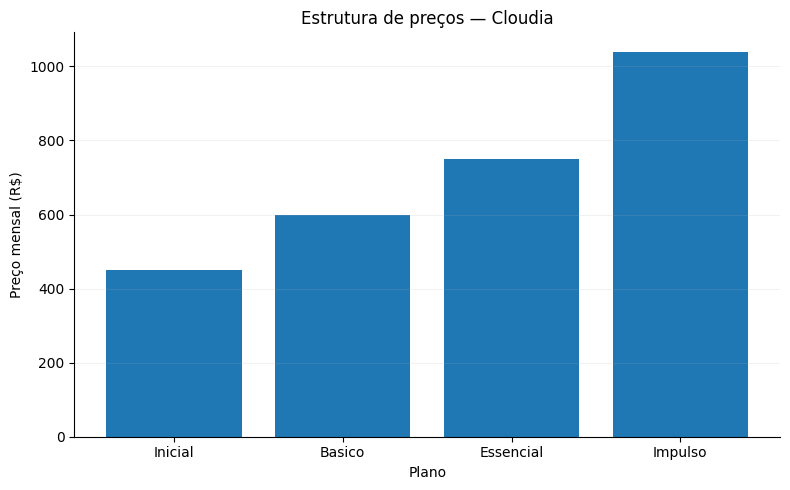

In [14]:
df_plot = df_cloudia.dropna(subset=["preco_mensal_brl"]).copy()

plt.figure(figsize=(8, 5))

plt.bar(df_plot["plano"], df_plot["preco_mensal_brl"])

plt.ylabel("Preço mensal (R$)")
plt.xlabel("Plano")
plt.title("Estrutura de preços — Cloudia")

plt.grid(True, axis="y", linewidth=0.6, alpha=0.20)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "cloudia_precos_por_plano.png", dpi=200)
plt.show()


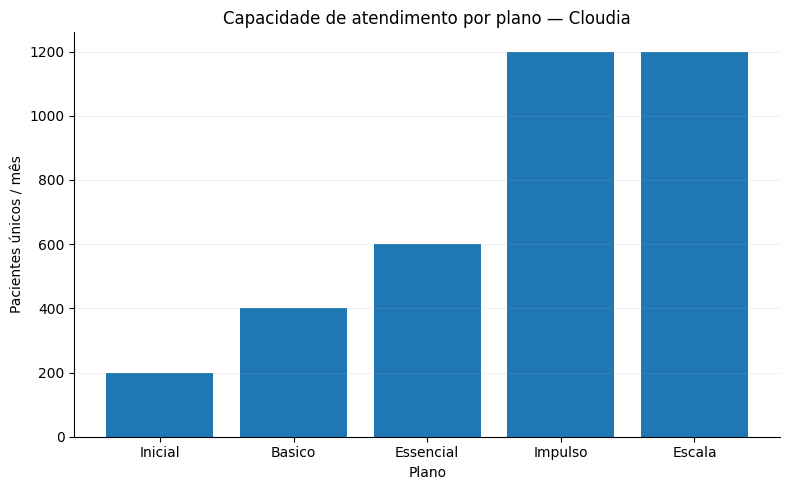

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(df_cloudia["plano"], df_cloudia["pacientes_unicos_mes"])

plt.ylabel("Pacientes únicos / mês")
plt.xlabel("Plano")
plt.title("Capacidade de atendimento por plano — Cloudia")

plt.grid(True, axis="y", linewidth=0.6, alpha=0.20)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "cloudia_pacientes_por_plano.png", dpi=200)
plt.show()


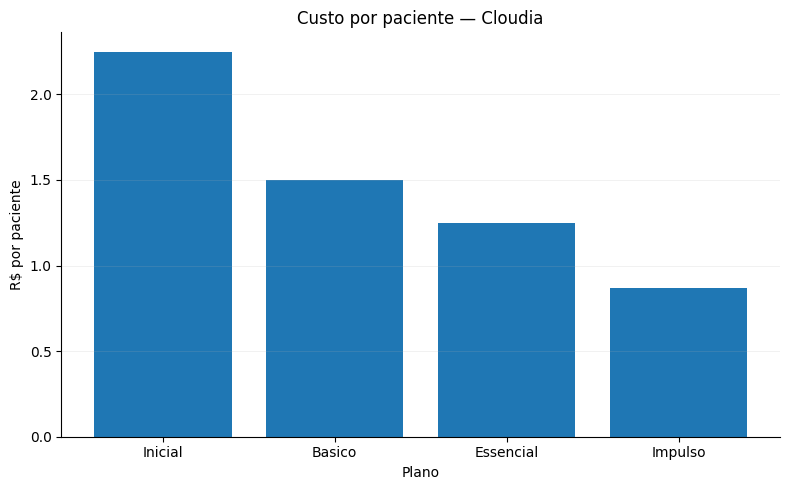

In [16]:
df_custo = df_cloudia.dropna(subset=["preco_mensal_brl"]).copy()

df_custo["custo_por_paciente"] = (
    df_custo["preco_mensal_brl"] /
    df_custo["pacientes_unicos_mes"]
)

plt.figure(figsize=(8, 5))

plt.bar(df_custo["plano"], df_custo["custo_por_paciente"])

plt.ylabel("R$ por paciente")
plt.xlabel("Plano")
plt.title("Custo por paciente — Cloudia")

plt.grid(True, axis="y", linewidth=0.6, alpha=0.20)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "cloudia_custo_por_paciente.png", dpi=200)
plt.show()


In [17]:
FEATURES_PATH = ROOT / "data" / "features.csv"
CF_PATH = ROOT / "data" / "concorrente_feature.csv"

df_features = pd.read_csv(FEATURES_PATH)
df_cf = pd.read_csv(CF_PATH)

df_features.head(), df_cf.head()


(            feature   categoria
 0          WhatsApp  multicanal
 1         Instagram  multicanal
 2         Messenger  multicanal
 3           Webchat  multicanal
 4  Disparo em massa   automacao,
   concorrente           feature  possui
 0     Cloudia          WhatsApp       1
 1     Cloudia         Instagram       1
 2     Cloudia         Messenger       1
 3     Cloudia           Webchat       1
 4     Cloudia  Disparo em massa       1)

In [18]:
matriz = df_cf.pivot_table(
    index="feature",
    columns="concorrente",
    values="possui",
    fill_value=0
)

matriz


concorrente,Blip,Cloudia,Huggy,Nosso SaaS
feature,,,,
Agenda integrada,0.0,1.0,0.0,1.0
Audio,0.0,1.0,0.0,1.0
CRM,1.0,1.0,1.0,1.0
Dashboard,1.0,1.0,1.0,1.0
Disparo em massa,1.0,1.0,1.0,1.0
Encaminhamento humano,1.0,1.0,1.0,1.0
Fluxos automatizados,1.0,1.0,1.0,1.0
Follow-up automatico,0.0,0.0,0.0,1.0
Funil de vendas,1.0,1.0,1.0,1.0


In [19]:
# Junta categoria
matriz = matriz.merge(
    df_features,
    left_index=True,
    right_on="feature"
)

matriz = matriz.sort_values("categoria").set_index("feature")

matriz


,Blip,Cloudia,Huggy,Nosso SaaS,categoria
feature,,,,,
Dashboard,1.0,1.0,1.0,1.0,analytics
Relatorios,1.0,1.0,1.0,1.0,analytics
Encaminhamento humano,1.0,1.0,1.0,1.0,atendimento
Disparo em massa,1.0,1.0,1.0,1.0,automacao
Fluxos automatizados,1.0,1.0,1.0,1.0,automacao
Sequencias,1.0,1.0,1.0,1.0,automacao
Audio,0.0,1.0,0.0,1.0,experiencia
CRM,1.0,1.0,1.0,1.0,gestao
Funil de vendas,1.0,1.0,1.0,1.0,gestao


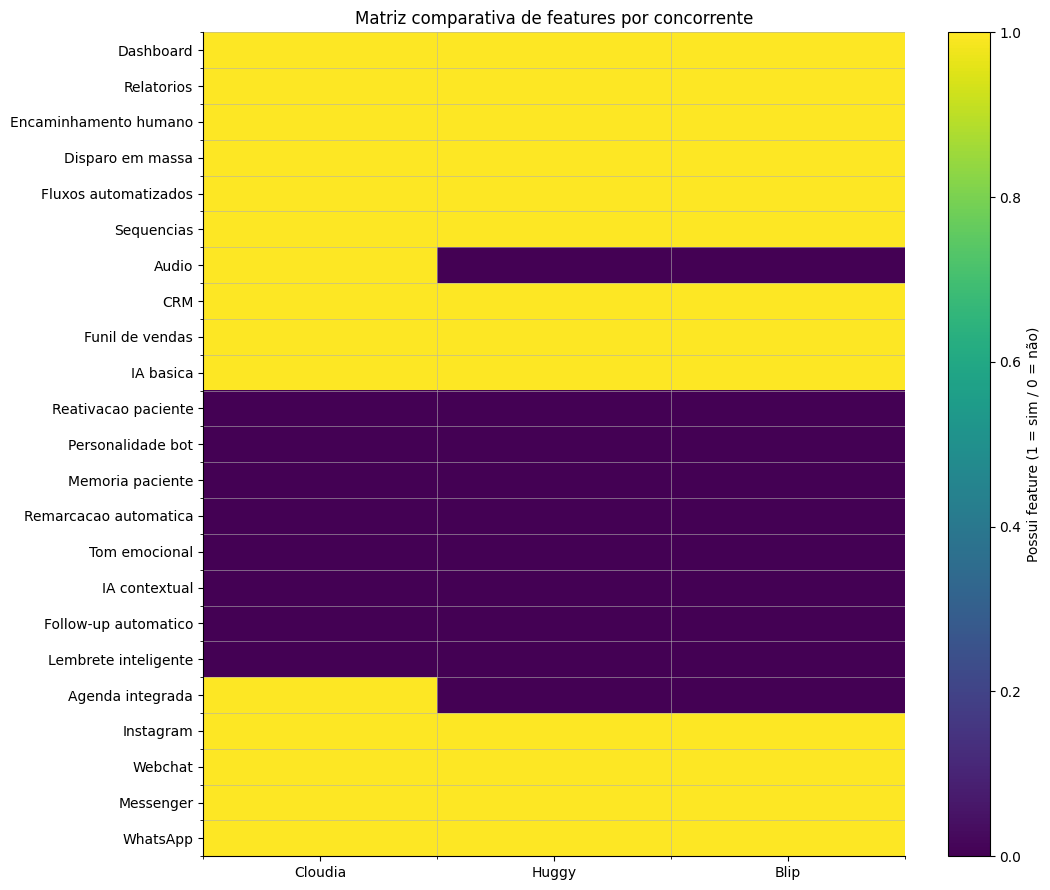

In [20]:
plt.figure(figsize=(11, 9))

data = matriz[["Cloudia", "Huggy", "Blip"]].to_numpy()

plt.imshow(data, aspect="auto")

# ticks
plt.xticks(
    range(3),
    ["Cloudia", "Huggy", "Blip"]
)

plt.yticks(
    range(len(matriz.index)),
    matriz.index
)

# grid interno
plt.gca().set_xticks(np.arange(-.5, 3, 1), minor=True)
plt.gca().set_yticks(np.arange(-.5, len(matriz.index), 1), minor=True)
plt.grid(which="minor", linestyle="-", linewidth=0.4)

# remover bordas pesadas
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Matriz comparativa de features por concorrente")
plt.colorbar(label="Possui feature (1 = sim / 0 = não)")

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "heatmap_features_concorrentes_v2.png", dpi=200)

plt.show()


In [21]:
matriz_ia = matriz.copy()

# manter só features de IA avançada
matriz_ia = matriz_ia[
    matriz_ia["categoria"] == "ia_avancada"
]

matriz_ia = matriz_ia[["Cloudia", "Huggy", "Blip"]]

matriz_ia


,Cloudia,Huggy,Blip
feature,,,
Reativacao paciente,0.0,0.0,0.0
Personalidade bot,0.0,0.0,0.0
Memoria paciente,0.0,0.0,0.0
Remarcacao automatica,0.0,0.0,0.0
Tom emocional,0.0,0.0,0.0
IA contextual,0.0,0.0,0.0
Follow-up automatico,0.0,0.0,0.0
Lembrete inteligente,0.0,0.0,0.0


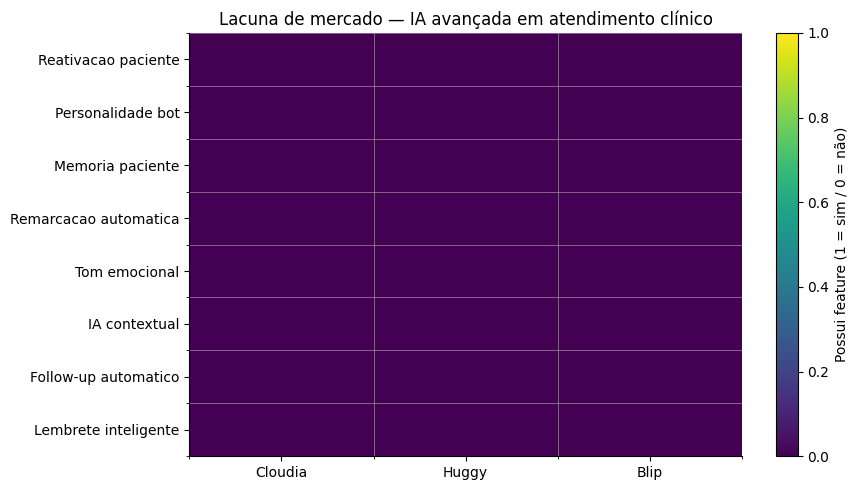

In [22]:
plt.figure(figsize=(9, 5))

data = matriz_ia.to_numpy()

plt.imshow(
    data,
    aspect="auto",
    vmin=0,
    vmax=1
)

plt.xticks(
    range(3),
    ["Cloudia", "Huggy", "Blip"]
)

plt.yticks(
    range(len(matriz_ia.index)),
    matriz_ia.index
)

# grid interno
plt.gca().set_xticks(np.arange(-.5, 3, 1), minor=True)
plt.gca().set_yticks(np.arange(-.5, len(matriz_ia.index), 1), minor=True)
plt.grid(which="minor", linestyle="-", linewidth=0.4)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Lacuna de mercado — IA avançada em atendimento clínico")
plt.colorbar(label="Possui feature (1 = sim / 0 = não)")

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "heatmap_ia_avancada_v2.png", dpi=200)

plt.show()



In [23]:
contagem = matriz[["Cloudia", "Huggy", "Blip"]].sum()

contagem


Cloudia    15.0
Huggy      13.0
Blip       13.0
dtype: float64

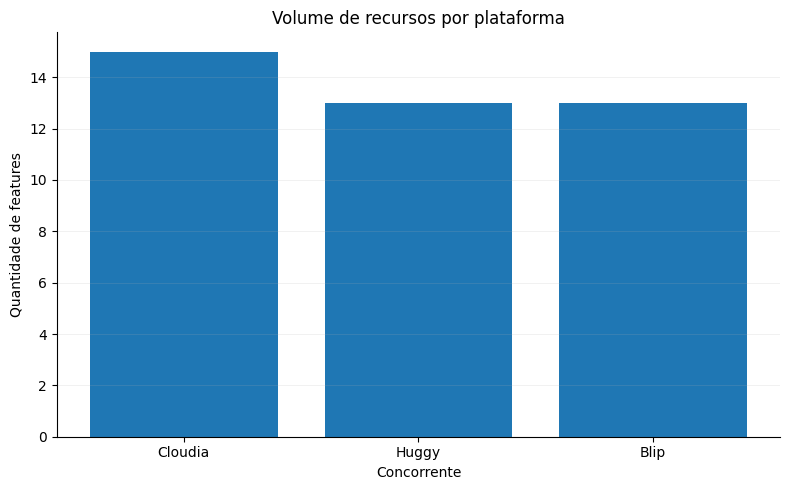

In [24]:
plt.figure(figsize=(8, 5))

labels = contagem.index
valores = contagem.values

plt.bar(labels, valores)

plt.ylabel("Quantidade de features")
plt.xlabel("Concorrente")
plt.title("Volume de recursos por plataforma")

plt.grid(True, axis="y", linewidth=0.6, alpha=0.20)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "contagem_features_concorrentes.png", dpi=200)
plt.show()


In [25]:
# Recarregar CSV atualizado
df_cf = pd.read_csv(CF_PATH)

# Recriar matriz
matriz = df_cf.pivot_table(
    index="feature",
    columns="concorrente",
    values="possui",
    fill_value=0
)

# Juntar categorias novamente
matriz = matriz.merge(
    df_features,
    left_index=True,
    right_on="feature"
)

matriz = matriz.sort_values("categoria").set_index("feature")

matriz.head()


,Blip,Cloudia,Huggy,Nosso SaaS,categoria
feature,,,,,
Dashboard,1.0,1.0,1.0,1.0,analytics
Relatorios,1.0,1.0,1.0,1.0,analytics
Encaminhamento humano,1.0,1.0,1.0,1.0,atendimento
Disparo em massa,1.0,1.0,1.0,1.0,automacao
Fluxos automatizados,1.0,1.0,1.0,1.0,automacao


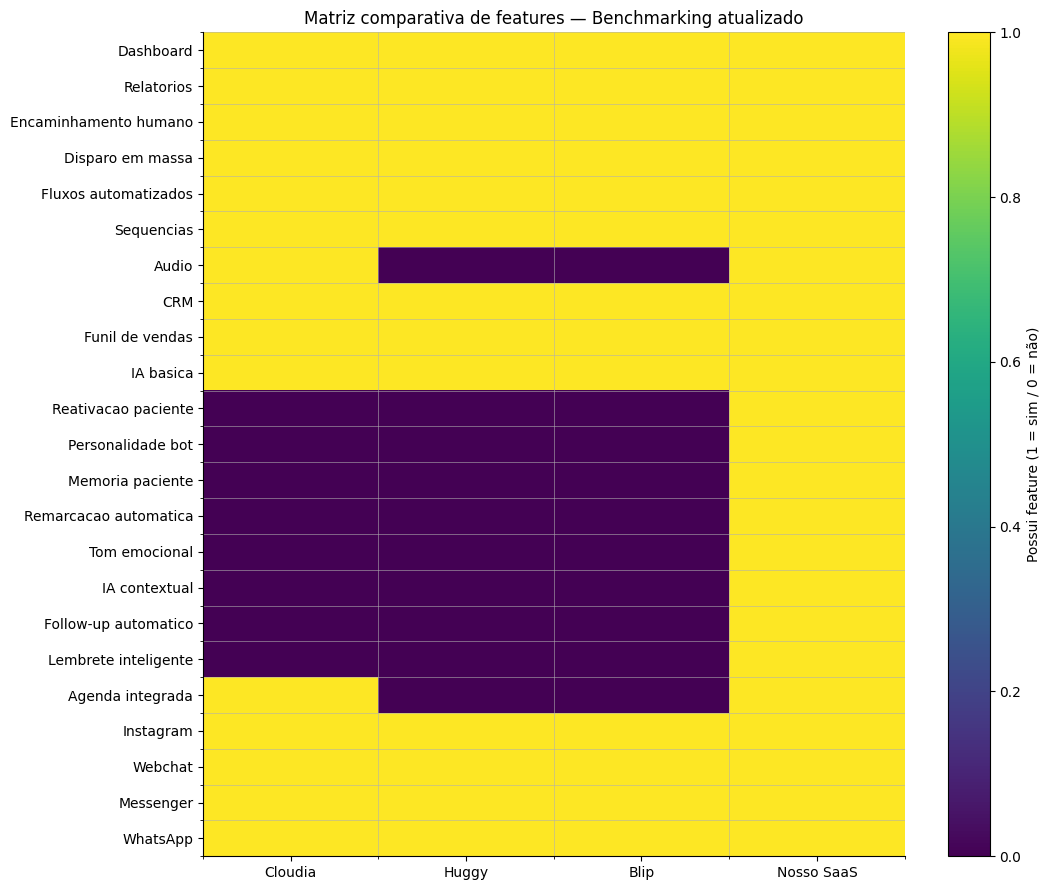

In [26]:
plt.figure(figsize=(11, 9))

data = matriz[["Cloudia", "Huggy", "Blip", "Nosso SaaS"]].to_numpy()

plt.imshow(
    data,
    aspect="auto",
    vmin=0,
    vmax=1
)

plt.xticks(
    range(4),
    ["Cloudia", "Huggy", "Blip", "Nosso SaaS"]
)

plt.yticks(
    range(len(matriz.index)),
    matriz.index
)

# grid interno
plt.gca().set_xticks(np.arange(-.5, 4, 1), minor=True)
plt.gca().set_yticks(np.arange(-.5, len(matriz.index), 1), minor=True)
plt.grid(which="minor", linestyle="-", linewidth=0.4)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Matriz comparativa de features — Benchmarking atualizado")
plt.colorbar(label="Possui feature (1 = sim / 0 = não)")

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "heatmap_features_com_nosso_saas.png", dpi=200)

plt.show()


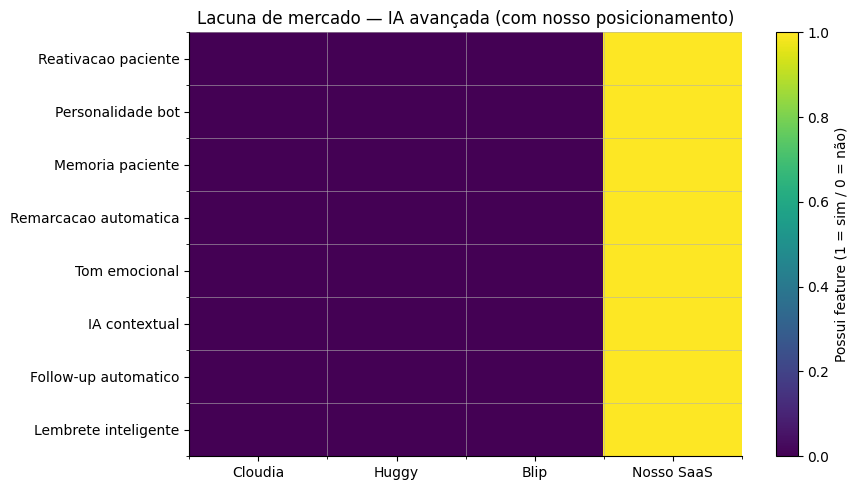

In [27]:
matriz_ia = matriz[
    matriz["categoria"] == "ia_avancada"
][["Cloudia", "Huggy", "Blip", "Nosso SaaS"]]

plt.figure(figsize=(9, 5))

data = matriz_ia.to_numpy()

plt.imshow(
    data,
    aspect="auto",
    vmin=0,
    vmax=1
)

plt.xticks(
    range(4),
    ["Cloudia", "Huggy", "Blip", "Nosso SaaS"]
)

plt.yticks(
    range(len(matriz_ia.index)),
    matriz_ia.index
)

plt.gca().set_xticks(np.arange(-.5, 4, 1), minor=True)
plt.gca().set_yticks(np.arange(-.5, len(matriz_ia.index), 1), minor=True)
plt.grid(which="minor", linestyle="-", linewidth=0.4)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Lacuna de mercado — IA avançada (com nosso posicionamento)")
plt.colorbar(label="Possui feature (1 = sim / 0 = não)")

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "heatmap_ia_avancada_com_nosso_saas.png", dpi=200)

plt.show()


In [28]:
# Escala: 1=Baixo, 2=Médio, 3=Alto
# complexidade: vamos inverter depois (menos complexidade = melhor)

radar = pd.DataFrame({
    "concorrente": ["Cloudia", "Huggy", "Blip", "Nosso SaaS"],
    "humanizacao": [2, 1, 1, 3],
    "ia":          [2, 1, 2, 3],
    "velocidade":  [1, 3, 3, 3],
    "complexidade":[2, 1, 3, 1],  # 1 = baixa (bom), 3 = alta (ruim)
    "saude":       [2, 1, 1, 3]
})

radar


,concorrente,humanizacao,ia,velocidade,complexidade,saude
0,Cloudia,2,2,1,2,2
1,Huggy,1,1,3,1,1
2,Blip,1,2,3,3,1
3,Nosso SaaS,3,3,3,1,3


In [29]:
radar_plot = radar.copy()
radar_plot["atrio_baixo"] = 4 - radar_plot["complexidade"]  # 1->3, 2->2, 3->1

radar_plot


,concorrente,humanizacao,ia,velocidade,complexidade,saude,atrio_baixo
0,Cloudia,2,2,1,2,2,2
1,Huggy,1,1,3,1,1,3
2,Blip,1,2,3,3,1,1
3,Nosso SaaS,3,3,3,1,3,3


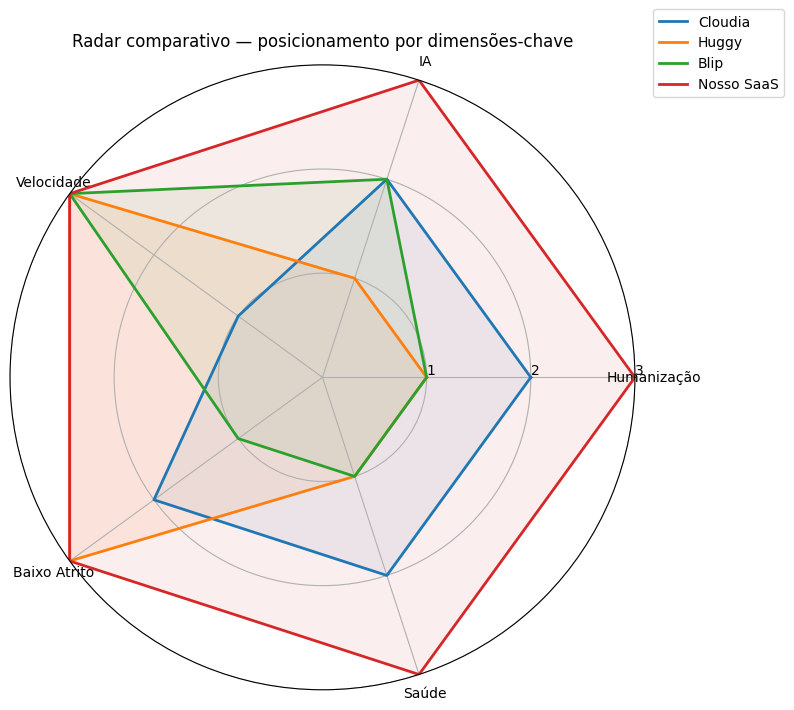

In [30]:
import numpy as np

categorias = ["humanizacao", "ia", "velocidade", "atrio_baixo", "saude"]
rotulos = ["Humanização", "IA", "Velocidade", "Baixo Atrito", "Saúde"]

N = len(categorias)
angulos = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]  # fechar

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# eixo
plt.xticks(angulos[:-1], rotulos)
ax.set_rlabel_position(0)
plt.yticks([1, 2, 3], ["1", "2", "3"])
plt.ylim(0, 3)

# plotar cada concorrente
for _, row in radar_plot.iterrows():
    valores = row[categorias].tolist()
    valores += valores[:1]  # fechar
    ax.plot(angulos, valores, linewidth=2, label=row["concorrente"])
    ax.fill(angulos, valores, alpha=0.08)

plt.title("Radar comparativo — posicionamento por dimensões-chave")
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))

plt.tight_layout()
plt.savefig(OUTPUTS_GRAFICOS / "radar_posicionamento.png", dpi=200)
plt.show()


In [31]:
tabela_exec = pd.DataFrame({
    "Concorrente": ["Cloudia", "Huggy", "Blip", "Nosso SaaS"],
    "Humanização": ["Média", "Baixa", "Baixa", "Muito alta"],
    "IA": ["Boa", "Fraca", "Média", "Muito alta"],
    "Velocidade": ["Lenta", "Rápida", "Rápida", "Rápida"],
    "Complexidade": ["Média", "Baixa", "Alta", "Baixa"],
    "Saúde (nicho)": ["Média", "Baixa", "Baixa", "Total"],
    "Resumo": [
        "Bom baseline + áudio; resposta lenta",
        "Omnichannel/marketing; engessado e lead-centric",
        "Infra robusta; complexo e pouco humanizado",
        "IA contextual + memória + emoção; foco em jornada clínica"
    ]
})

tabela_exec


,Concorrente,Humanização,IA,Velocidade,Complexidade,Saúde (nicho),Resumo
0,Cloudia,Média,Boa,Lenta,Média,Média,Bom baseline + áudio; resposta lenta
1,Huggy,Baixa,Fraca,Rápida,Baixa,Baixa,Omnichannel/marketing; engessado e lead-centric
2,Blip,Baixa,Média,Rápida,Alta,Baixa,Infra robusta; complexo e pouco humanizado
3,Nosso SaaS,Muito alta,Muito alta,Rápida,Baixa,Total,IA contextual + memória + emoção; foco em jorn...


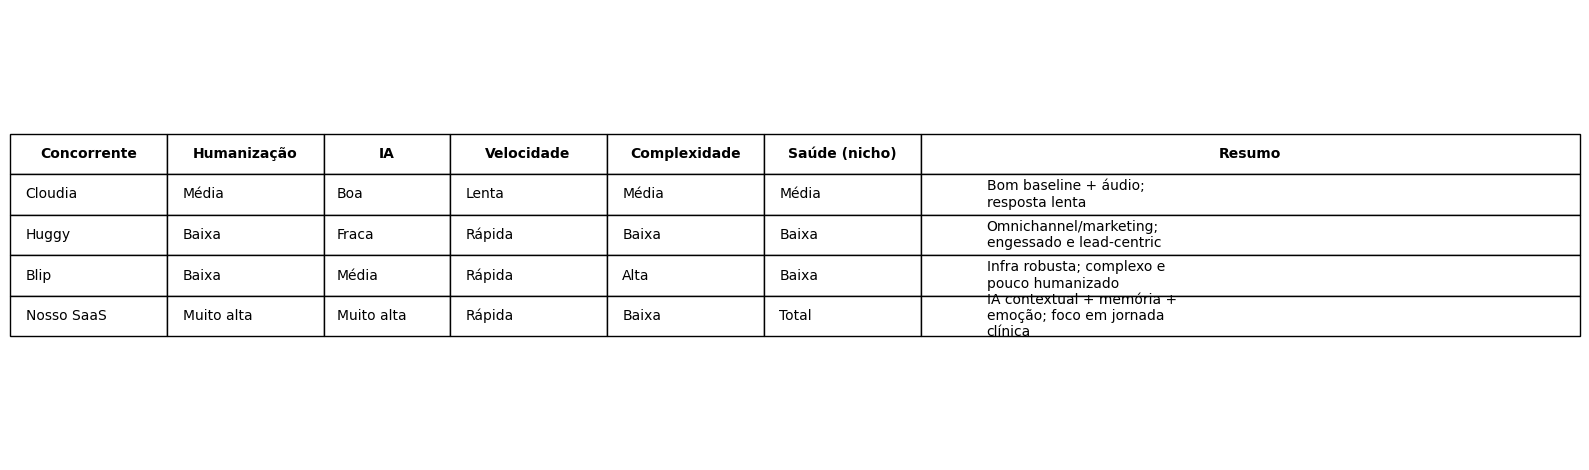

In [36]:
import textwrap

def wrap_text(text, width=28):
    return "\n".join(textwrap.wrap(str(text), width))

tabela_exec_wrap = tabela_exec.copy()
tabela_exec_wrap["Resumo"] = tabela_exec_wrap["Resumo"].apply(lambda x: wrap_text(x, 28))

fig, ax = plt.subplots(figsize=(16, 4.8))
ax.axis("off")

colunas = tabela_exec_wrap.columns.tolist()
dados = tabela_exec_wrap.values.tolist()

# Larguras (soma ~ 1.0). Dê mais espaço pro Resumo.
col_widths = [0.10, 0.10, 0.08, 0.10, 0.10, 0.10, 0.42]

tbl = ax.table(
    cellText=dados,
    colLabels=colunas,
    cellLoc="left",
    loc="center",
    colWidths=col_widths
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.0)

# Header em negrito
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")

plt.tight_layout()
plt.savefig(
    OUTPUTS_GRAFICOS / "tabela_resumo_exec_v4.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()




In [37]:
tabela_cloudia = df_cloudia.copy()

# calcular custo por paciente (só onde tem preço)
tabela_cloudia["custo_por_paciente"] = (
    tabela_cloudia["preco_mensal_brl"] / tabela_cloudia["pacientes_unicos_mes"]
)

# selecionar e renomear colunas para apresentação
tabela_cloudia = tabela_cloudia[[
    "plano",
    "preco_mensal_brl",
    "usuarios_limite",
    "pacientes_unicos_mes",
    "custo_por_paciente"
]].rename(columns={
    "plano": "Plano",
    "preco_mensal_brl": "Preço/mês (R$)",
    "usuarios_limite": "Usuários",
    "pacientes_unicos_mes": "Pacientes/mês",
    "custo_por_paciente": "R$/paciente"
})

# arredondar só para visual (não altera o df original)
tabela_cloudia["Preço/mês (R$)"] = tabela_cloudia["Preço/mês (R$)"].round(2)
tabela_cloudia["R$/paciente"] = tabela_cloudia["R$/paciente"].round(2)

tabela_cloudia


,Plano,Preço/mês (R$),Usuários,Pacientes/mês,R$/paciente
0,Inicial,449.9,5,200,2.25
1,Basico,599.9,5,400,1.50
2,Essencial,749.9,5,600,1.25
3,Impulso,1039.9,5,1200,0.87
4,Escala,NaN,5,1200,NaN


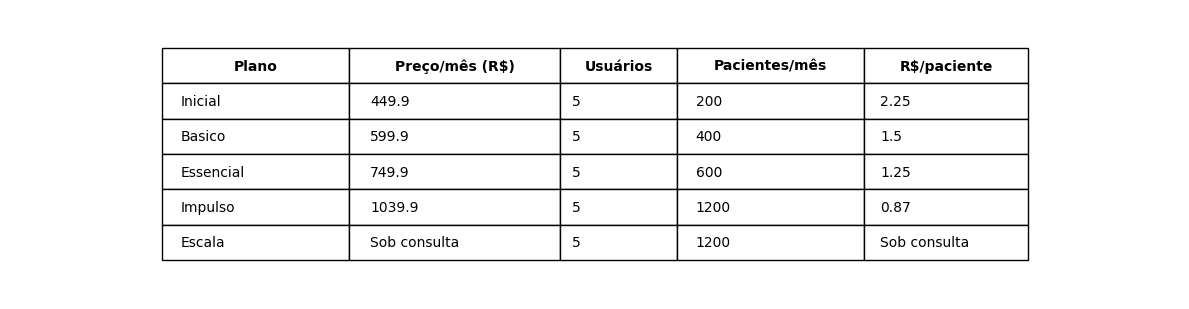

In [38]:
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.axis("off")

colunas = tabela_cloudia.columns.tolist()
dados = tabela_cloudia.fillna("Sob consulta").values.tolist()

# Larguras bem distribuídas
col_widths = [0.16, 0.18, 0.10, 0.16, 0.14]

tbl = ax.table(
    cellText=dados,
    colLabels=colunas,
    cellLoc="left",
    loc="center",
    colWidths=col_widths
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)

# Header em negrito
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")

plt.tight_layout()
plt.savefig(
    OUTPUTS_GRAFICOS / "tabela_planos_cloudia.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()


In [39]:
tabela_ia = matriz_ia.copy()

# Converter 0/1 para Não/Sim (bem mais apresentável)
tabela_ia = tabela_ia.replace({0: "Não", 1: "Sim"})

tabela_ia


,Cloudia,Huggy,Blip,Nosso SaaS
feature,,,,
Reativacao paciente,Não,Não,Não,Sim
Personalidade bot,Não,Não,Não,Sim
Memoria paciente,Não,Não,Não,Sim
Remarcacao automatica,Não,Não,Não,Sim
Tom emocional,Não,Não,Não,Sim
IA contextual,Não,Não,Não,Sim
Follow-up automatico,Não,Não,Não,Sim
Lembrete inteligente,Não,Não,Não,Sim


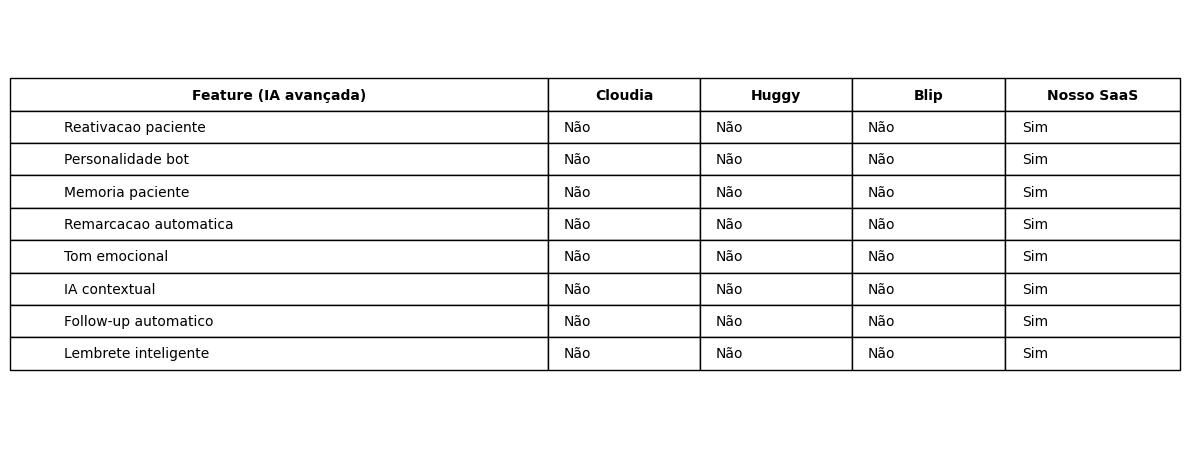

In [40]:
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.axis("off")

colunas = ["Cloudia", "Huggy", "Blip", "Nosso SaaS"]
dados = tabela_ia[colunas].values.tolist()
linhas = tabela_ia.index.tolist()

# Criar tabela com a primeira coluna sendo o nome da feature
cell_text = [[linhas[i]] + dados[i] for i in range(len(linhas))]
col_labels = ["Feature (IA avançada)"] + colunas

# Larguras: dá bastante espaço pra coluna de feature
col_widths = [0.46, 0.13, 0.13, 0.13, 0.15]

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="left",
    loc="center",
    colWidths=col_widths
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

# Header em negrito
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")

plt.tight_layout()
plt.savefig(
    OUTPUTS_GRAFICOS / "tabela_lacuna_ia_avancada.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()
